Load required libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import BoundaryNorm
from scipy.sparse import lil_matrix

%config InlineBackend.figure_format='retina'

Entropy Rate Superpixel Segmentation

In [52]:
class Node:
    """
    Class representing a node in the image graph.
    
    Each node corresponds to a pixel in the image.
    
    Attributes :
        x (int) : Column index of the pixel
        y (int) : Row index of the pixel
        intensity (float (n,)) : Array of intensities in each spectral band
        index (int) : Index for referencing in graph algorithms
        
    """
    
    def __init__(self, i, j, I, index = None):
        self.x = i 
        self.y = j 
        self.intensity = I 
        self.index = index
        
    
    def __str__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"
    
    def __repr__(self):
        return f"Node(x={self.x}, y={self.y}, intensity={self.intensity}, index={self.index})"

In [ ]:
class Edge:
    """
    Class representing an edge in the image graph.
    
    Each edge connects two nodes (pixels). One of the nodes is assigned as the owner and the other as the neighbor.
    
    Attributes :
        owner (int) : Index of the owner node
        neighbor (int) : Index of the neighbor node
        weight (float) : Weight assigned to the edge based on spectral spectral proximity of its nodes
        index (int) : Index for referencing in graph algorithms
        
    """
    def __init__(self, owner, neighbor, weight, index = None):
        self.owner = owner
        self.neighbor = neighbor
        self.weight = weight
        self.index = index
                    
    def __str__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
    
    def __repr__(self):
        return f"Edge(owner={self.owner}, neighbor={self.neighbor}, weight={self.weight}, index={self.index})"
        

In [ ]:
def gaussian_kernel(owner, neighbor, **kernel_args):
    """
    Function to compute edge weights using the gaussian kernel
    
    """
    
    sigma = kernel_args.get('sigma', 5.0)
    
    # Spatial proximity
    d = np.sqrt(((owner.x-neighbor.x))**2 + ((owner.y-neighbor.y))**2)
    
    # Spectral proximity
    i = np.linalg.norm(owner.intensity - neighbor.intensity)
    
    return np.exp(-((d * i) ** 2) / (2 * sigma ** 2))

In [42]:
class ImgGraph:
    """ 
    Class representing a graph constructed from an image, where each pixel is a node 
    and edges connect neighboring pixels.
    
    The graph supports both 4- and 8-connectivity, and edge weights are computed using a 
    user-defined kernel function (only Gaussian kernel implemented).
    
    Attributes:
        image (ndarray): Input image, potentially multi-spectral (shape: rows x cols x bands).
        rows (int): Number of rows (height) in the image.
        cols (int): Number of columns (width) in the image.
        n (int): Total number of nodes (pixels) in the graph.
        nEdges (int): Total number of edges based on the connectivity.
        V (Node (n,)): Array of Node objects.
        E (Edge (nEdges,)): Array of Edge objects.
        edgesV ([] (n,)): List of edge indices connected to each node.
        W_V (float (n,)): Total incident weight at each node (used in spectral methods).
        W_T (float): Total sum of all edge weights in the graph.

    """
    
    def __init__(self, image, kernel, conn8 = False, **kernel_args):
        
        """
        Initializes the image graph.

        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        
        self.image = image
        self.rows, self.cols = self.image.shape[0:2]
        self.n = self.rows*self.cols
        
        if conn8 is True:
            # Define 8-neighbor connectivity (sw, s, se, w, e, nw, n, ne)
            neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1) + 2*(self.rows-1)*(self.cols-1)
        else:
            # Define 4-neighbor connectivity (s, w, e, n)
            neighbors = [(-1,0), (0, -1), (0, 1), (1, 0)]
            self.nEdges = self.rows*(self.cols-1) + self.cols*(self.rows-1)
        
        
        # Initialize vertices array
        self.V = np.empty(self.n, dtype=object)
        
        # Initialize edges array
        self.E = np.empty(self.nEdges, dtype=object)
        
        # Counter for number of edges added
        nEdgesAdded = 0 
        
        # Array of indices of edges connected to vertices
        self.edgesV = np.empty(self.n, dtype=object)
        
        for i in range(self.n):
            self.edgesV[i] = []     
        
        # Initialize array of total incident weights at vertices
        self.W_V = np.zeros(self.n, dtype=float)
        
        # Assemble graph
        
        # Add nodes 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
                self.V[ind] = Node(j,i,self.image[i,j,...],index=ind)
        
        # Add edges 
        for i in range(self.rows):
            for j in range(self.cols):
                ind = i*self.cols + j
            
                for dx, dy in neighbors:
                    # Coordinates of neighbor node
                    ni, nj = i + dx, j + dy
                
                    if 0 <= ni < self.rows and 0 <= nj < self.cols:
                        # Index of neighbor node
                        nind = ni*self.cols + nj
                        
                        if ind < nind: # to ensure that edge is added only once
                            
                            # Compute edge weight
                            w = kernel(self.V[ind], self.V[nind], **kernel_args)

                            # Add weight to total incident weight at both nodes
                            self.W_V[ind] += w
                            self.W_V[nind] += w
                            
                            # Add edge
                            self.E[nEdgesAdded] = Edge(self.V[ind], self.V[nind], w, index = nEdgesAdded)
                            
                            # Add edge index to list of edges connected to each of the two nodes
                            self.edgesV[ind].append(nEdgesAdded)
                            self.edgesV[nind].append(nEdgesAdded)
                            
                            nEdgesAdded += 1
        
        # Check whether number of edges added is correct                   
        assert nEdgesAdded == self.nEdges, f"Expected {self.nEdges}, got {nEdgesAdded}"

        # Compute sum of weights of all edges (used for normalization later)
        self.W_T = np.sum(self.W_V)


In [44]:
class ERS():
    """ 
    ------------------------------------------------------------------------------------
    ERS (Entropy Rate Superpixel Segmentation) Algorithm Implementation
    ------------------------------------------------------------------------------------
    
    This class implements the ERS algorithm, a graph based segmentation method that partitions
    an image into a specified number (K) of superpixels, or clusters of connected pixels.
    
    The image is represented as a weighted graph where nodes are pixels and edges connect 
    neighboring pixels based on similarity (in this case, spectral proximity for hyperspectral images ).
    
    The optimization algorithm greedily selects edges to merge clusters, maximizing a combined 
    objective: Entropy Rate Gain (encourages homogeneity within clusters) and a
    Balancing Gain (promotes uniform region sizes).
    
    Methods:
        initialize : Constructs the graph from the image and initializes node/edge properties.
        setParams : Sets K (target number of superpixels) and alpha (weight given to balancing gain), and 
                computes initial edge gains.
        ERGain / BGain : Compute the respective gains to the objective when a given edge is selected.
        segment : Main loop where regions are iteratively merged by selecting the edge with the highest gain, 
                updating the corresponding labels and gain values, until only K clusters remain.
    
    Output:
        labels_matrix : A 2D array with the same dimensions as the input image, where each pixel 
        is labeled by its corresponding superpixel index.
        
    Usage:
        1. Instantiate: ers = ERS()
        2. Initialize: ers.initialize(image, kernel)
        3. Set parameters and compute initial gains: ers.setParams(K=desired_superpixels, alpha=balancing_weight)
        4. Run segmentation iterations: ers.segment()
        
    """
    def initialize(self, image, kernel, conn8 = False, **kernel_args):
        """ 
        Args:
            image (ndarray): Input image.
            kernel (function): A function that takes two Node objects and returns a scalar weight.
            conn8 (bool): Whether to use 8-connectivity (default is 4-connectivity).
            **kernel_args: Additional arguments to pass to the kernel function.
            
        """
        # Create an ImgGraph object for the image
        self.imgGraph = ImgGraph(image, kernel, conn8, **kernel_args)
        
        # Initialize an array that will store 1 if edge with given index is selected  
        self.edges_added = np.zeros(self.imgGraph.nEdges, dtype=int)
        
        # Initialize array of labels each node belongs to (Initially each node has unique label)
        self.labels = np.arange(0,self.imgGraph.n)
        
        # Initialize self weights (normalized) of nodes (this needs to be updated each time an edge is added to A)
        self.selfW = self.imgGraph.W_V / self.imgGraph.W_T
        
        # Initialize edge weights (normalized)
        self.edgeW = np.array([e.weight for e in self.imgGraph.E]) / self.imgGraph.W_T
    
    def setParams(self, K, alpha):
        """ 
        Args:
            K (int): Desired number of superpixels
            alpha (float): Weight given to balancing gain
            
        """
        self.K = K 
        
        ERGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        BGains = np.zeros(self.imgGraph.nEdges, dtype=float)
        
        # Compute initial weights for all edges
        for e in self.imgGraph.E:
            edgeIndex = e.index
            ERGains[edgeIndex] = self.ERGain(edgeIndex)
            BGains[edgeIndex] = self.BGain(edgeIndex)
        
        self.alpha = alpha
        
        beta = np.max(ERGains)/np.max(BGains)
        
        # Compute corrected balancing weight based on data
        self.alphaCorr = alpha*beta*K

        self.gains = ERGains + self.alphaCorr*BGains
        
    def ERGain(self, edgeIndex):
        """ 
            Compute the Entropy Rate gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        c_i = self.selfW[i]
        c_j = self.selfW[j]
        w_ij = self.edgeW[edgeIndex]
        
        eps = 1e-8
        
        H_old = -c_i*np.log2(c_i+eps) -c_j*np.log2(c_j+eps)
        H_new = -(c_i-w_ij)*np.log2(c_i-w_ij+eps) -(c_j-w_ij)*np.log2(c_j-w_ij+eps) -2*w_ij*np.log2(w_ij+eps)
        H_gain = (H_new - H_old)
        
        if np.isnan(H_gain):
            H_gain = -1e6
            
        return H_gain
    
    def BGain(self, edgeIndex):
        """ 
            Compute the Balancing gain for an edge.
        """
        
        # If edge has already been added, return -1e6 (i.e. it should not be added)
        if self.edges_added[edgeIndex] == 1:
            return -1e6
        
        # Get labels for both nodes of the edge    
        i = self.imgGraph.E[edgeIndex].owner.index
        j = self.imgGraph.E[edgeIndex].neighbor.index
        
        label_i = self.labels[i]
        label_j = self.labels[j]
        
        # Check if the nodes belong to different labels, otherwise return -1e6 (i.e. it should not be added, as it will lead to cycles)
        if label_i == label_j:
            return -1e6
        
        # Get number of nodes in each of the superpixels
        count_i = np.sum(self.labels == label_i)
        count_j = np.sum(self.labels == label_j)
        
        # Normalize
        S_i = count_i*1.0/self.imgGraph.n
        S_j = count_j*1.0/self.imgGraph.n
        
        B_gain = (- (S_i+S_j)*np.log2(S_i+S_j) + S_i*np.log2(S_i) + S_j*np.log2(S_j)) +     1
        
        if np.isnan(B_gain):
            B_gain = -1e6
            
        return B_gain

    def segment(self):
        """ 
        Function that performs the segmentation iterations
        """
        
        self.nSupPix = self.imgGraph.n # Initially, all nodes are disconnected
        
        while self.nSupPix > self.K:
            
            print("\nNumber of clusters:", self.nSupPix)
            # Get edge index with maximum gain
            maxGainEdgeIndex = np.argmax(self.gains)
            print("\nMax Gain: ",self.gains[maxGainEdgeIndex])
            
            if (self.gains[maxGainEdgeIndex] <= 0):
                break
            
            # Add edge to set 
            self.edges_added[maxGainEdgeIndex] = 1
            
            # Update gain of edge to -1e6 (so that it is not considered anymore)
            self.gains[maxGainEdgeIndex] = -1e6
            
            # Get index of owner and neighbor nodes
            owner = self.imgGraph.E[maxGainEdgeIndex].owner.index
            neighbor = self.imgGraph.E[maxGainEdgeIndex].neighbor.index
            
            # Get labels of owner and neighbor nodes
            owner_label = self.labels[owner]
            neighbor_label = self.labels[neighbor]
            
            # Change labels of all nodes having neighbor label to owner label
            self.labels[self.labels == neighbor_label] = owner_label
            
            # Update self weights of owner and neighbor nodes
            self.selfW[owner] -= self.edgeW[maxGainEdgeIndex]
            self.selfW[neighbor] -= self.edgeW[maxGainEdgeIndex]
            
            # Update gains for all edges connecting nodes that were in the two segments
            nodes_to_update = np.arange(self.imgGraph.n)[(self.labels == owner_label)]
            
            for nodeIndex in nodes_to_update:
                # Get indices of edges connecting each node
                edges = self.imgGraph.edgesV[nodeIndex]
                
                for edgeIndex in edges:
                    if edgeIndex != maxGainEdgeIndex:
                        ERGain_ = self.ERGain(edgeIndex)
                        BGain_ = self.BGain(edgeIndex)
                        self.gains[edgeIndex] = ERGain_ + self.alphaCorr*BGain_

            self.nSupPix = len(np.unique(self.labels))

        # Once the clustering is done, change labels such that they are from 0 to K-1.
        unique_labels = np.unique(self.labels)
        new_labels = np.arange(0, len(unique_labels))
        
        self.updated_labels = self.labels.copy()
        for i in range(len(unique_labels)):
            self.updated_labels[self.labels == unique_labels[i]] = new_labels[i]
        
        # Reshape into the same shape as the image
        self.labels_matrix = self.updated_labels.reshape(self.imgGraph.rows,self.imgGraph.cols)
        
        print(f"Segmented image into {self.nSupPix} superpixels.")
            

S3-PCA 

Function to split dataset into training and test data with fixed number of training samples for each label

In [45]:
def fixed_split(X, y, train_samples_per_class):
    """
    Function to split dataset into training and test data with fixed number of training samples for each label.
    
    For classes which have less samples than required, only half the samples are added to the training set.
    """
    
    X_train, X_test, y_train, y_test , indices_train, indices_test = [], [], [], [], [], []
    
    unique_labels = np.unique(y)
    
    for label in range(1,np.max(unique_labels)+1):
        indices = np.where(y == label)[0]  # Get all indices for the current label
        
        n_train = np.minimum(train_samples_per_class, int(np.floor(len(indices)/2)))

        # Shuffle indices randomly
        np.random.shuffle(indices)

        # Split into train and test
        train_indices = indices[:n_train]
        test_indices = indices[n_train:]

        # Append to train/test lists
        X_train.append(X[train_indices,:])
        X_test.append(X[test_indices,:])
        y_train.append(y[train_indices])
        y_test.append(y[test_indices])
        indices_train.append(train_indices)
        indices_test.append(test_indices)

    # Stack results
    X_train, X_test = np.vstack(X_train), np.vstack(X_test)
    y_train, y_test = np.hstack(y_train), np.hstack(y_test)
    indices_train, indices_test = np.hstack(indices_train), np.hstack(indices_test)
    
    return X_train, X_test, y_train, y_test, indices_train, indices_test

Function to perform PCA

In [46]:
def pca(X, nComponents, center = True):
    '''
        Function to get the principal components for a data matrix.
        
        The data matrix X consists of sample rows and feature columns.
        
        Args:
            nComponents (int): Number of principal components to output
            center (bool): Flag for whether to center data before performing SVD 
    '''
    
    import numpy as np
    
    if center:
        mean_sample = np.mean(X, axis=0, keepdims=True)
        
        X_centered = X - mean_sample
    
        U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
        components = VT[:nComponents,:]

        projected_X = X @ components.T
    
    else:
        U, S, VT = np.linalg.svd(X, full_matrices=False)

        components = VT[:nComponents,:]
        
        projected_X = X @ components.T
        
    return projected_X, components

Function to find distance between two pixel indices

In [47]:
def EuDist2(i1, i2, nX):
    """ 
    Function to find distance between two pixel indices.
    
    Args:
        i1 (int): Index of first pixel in flattened array
        i2 (int): Index of second pixel in flattened array
        nX (int): Number of columns in the image
    
    """
    
    x1 = i1 % nX
    y1 = i1 // nX
    
    x2 = i2 % nX
    y2 = i2 // nX
    
    return (x1-x2)**2 + (y1-y2)**2

Funtion to find distance matrix

In [48]:
def EuDist2Mat(indices, nX):
    """ 
    Function to find the distance matrix.
    
    The element (i, j) in the distance matrix is the distance between the pixels 
    with indices i and j in the flattened image.
    
    """
    d = np.zeros((len(indices),len(indices)))
    
    for i in range(len(indices)):
        d[i,:] = EuDist2(indices[i],indices,nX)
        
    return d

Function to reconstruct pixels in each superpixel

In [50]:
def reconstructSuperpixelDataMat(dataMat, indices, nX, k, criterion = "spectral"):
    """ 
    Function to reconstruct the spectral information of each pixel based on its 
    nearest neighboring pixels within the same superpixel.
    
    Args:
        dataMat (ndarray): Array with spectral information for all pixels in the superpixel.
        indices (ndarray): Array with indices in the flattened image for each pixel in the superpixel.
        nX (int): Number of columns in the image.
        k (int): Number of nearest neighbors to consider for reconstruction.
        criterion: The proximity criterion used for deciding weights given to neighboring pixels in reconstruction.
            "spectral" - Reconstruct based on spectral similarity.
            "spatial" - Reconstruct based on spatial proximity.
    
    """
    
    # Compute the distance matrix 
    distMat = EuDist2Mat(indices, nX)
    
    # Get the indices of the smallest k values in each row (i.e. the k nearest pixels)
    sorted_indices = np.argsort(distMat, axis=1)[:, :k+1]  
    
    weightMat = lil_matrix(distMat.shape)
    
    # Populate only the smallest k values in the sparse matrix
    for i in range(distMat.shape[0]):
        
        # Reconstruct based on spectral proximity
        if criterion == "spectral":
            temp = np.sum((dataMat[i,:] - dataMat[sorted_indices[i],:])**2,axis=1)
            
        # Reconstruct based on spatial proximity
        if criterion == "spatial":
            temp = np.sum((distMat[i,:] - distMat[sorted_indices[i],:])**2,axis=1)
            
        t = 1/k*np.sum(temp)
        
        weightMat[i,sorted_indices[i]] = np.exp(-temp/(2*t))/np.sum(np.exp(-temp/(2*t)))

    # Convert to CSR format for efficient matrix multiplication
    weightMat = weightMat.tocsr()   
    
    reconstructedDataMat = weightMat @ dataMat 
    
    return reconstructedDataMat
    

Function to construct superpixelwise data matrices from global data matrix 

In [51]:
def superpixelwiseDataMatFromGlobalDataMat(globalDataMat, segmentsVec):
    """ 
    Function to construct superpixelwise data matrices from the global data matrix.
    
    Returns a list of data matrices corresponding to different superpixel index, 
    and a list of arrays storing the global indices of each pixel in the superpixel matrix.
    
    """
    nPix = globalDataMat.shape[0]
    nBands = globalDataMat.shape[1]
    nSegments = segmentsVec.shape[0]
    
    superpixelwise_dataMat = []
    superpixelwise_indexVec = []

    
    for i in range(0,nSegments):
        segmentiMat =  np.empty((0, nBands))
        segmentiIndicesVec =  np.array([])
        superpixelwise_dataMat.append(segmentiMat)
        superpixelwise_indexVec.append(segmentiIndicesVec)
    
    for i in range(0,nPix):
        superpixelwise_dataMat[int(segmentsVec[i])] = np.vstack([superpixelwise_dataMat[segmentsVec[i]], globalDataMat[i,:]])
        superpixelwise_indexVec[int(segmentsVec[i])] = np.append(superpixelwise_indexVec[int(segmentsVec[i])], int(i))
        
    return superpixelwise_dataMat, superpixelwise_indexVec

Function to construct global data matrix from superpixelwise data matrices

In [53]:
def globalDataMatFromSuperpixelwiseDataMat(superpixelwise_dataMat, superpixelwise_indexVec):
    """
        Function to reassemble the global data matrix from the superpixelwise data matrices.
    """
    nPix = sum(len(v) for v in superpixelwise_indexVec)
    nBands = superpixelwise_dataMat[0].shape[1]
    nSegments = len(superpixelwise_indexVec)
    
    globalDataMat = np.zeros((nPix,nBands))
    
    for i in range(0,nSegments):
        for j in range(0,len(superpixelwise_indexVec[i])):
            pixel_index = int(superpixelwise_indexVec[i][j])
            globalDataMat[pixel_index,:] = superpixelwise_dataMat[i][j,:]
            
    return globalDataMat      

Load Data

In [54]:
data3D = scipy.io.loadmat("Data\Indian_pines_corrected.mat")
labels = scipy.io.loadmat("Data\Indian_pines_gt.mat")

View Data

In [15]:
print(data3D.keys())
print(labels.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])
dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [16]:
data3Darr = data3D['indian_pines_corrected']

# Normalize 
data3Darr = data3Darr/np.max(data3Darr) #np.max(data3D_array, axis=(0,1), keepdims=True) # 
labelsMat = labels['indian_pines_gt']

print(data3Darr.shape)

print(labelsMat.shape)

nY = data3Darr.shape[0]
nX = data3Darr.shape[1]
nBands = data3Darr.shape[2]
nPix = nX*nY

min_label = np.min(labelsMat)
max_label = np.max(labelsMat)

(145, 145, 200)
(145, 145)


In [17]:
norms = np.linalg.norm(data3Darr, axis=2)  # shape: (H, W)

mean_norm = np.mean(norms)
std_norm = np.std(norms)

print(f"Mean norm: {mean_norm}")
print(f"Std deviation of norm: {std_norm}")

Mean norm: 4.5451333550724025
Std deviation of norm: 0.3069957133306913


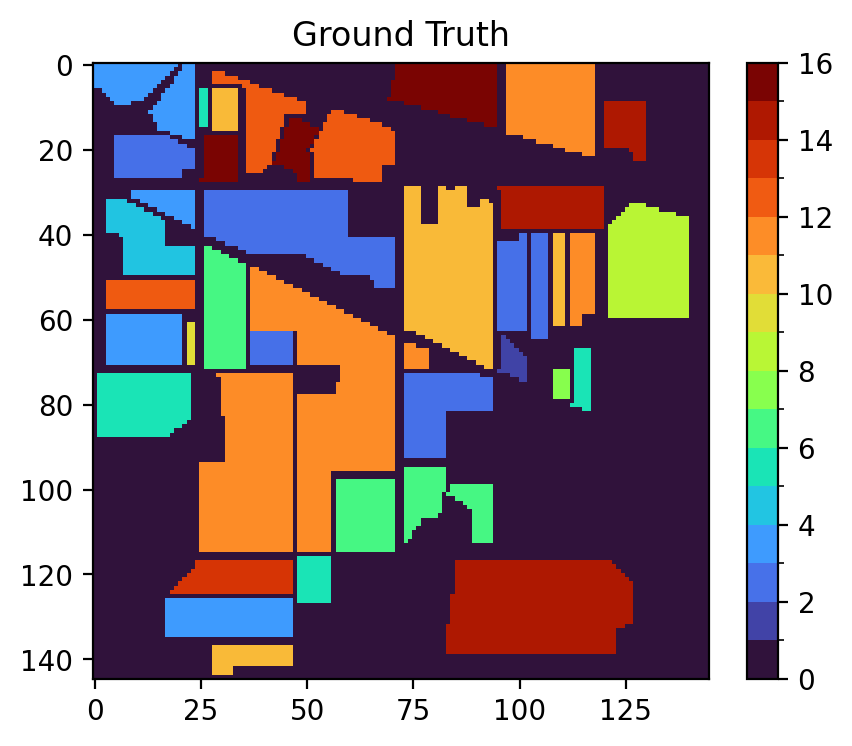

In [18]:
# Use Turbo colormap from Matplotlib
cmap = pl.cm.turbo

# Define discrete boundaries for the values (0 to 16)
bounds = np.arange(min_label, max_label+1, 1)  # Ensures correct mapping of colors
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(labelsMat, cmap=cmap,norm=norm)
pl.colorbar()
pl.title(r"Ground Truth")
pl.show()

In [19]:
# Get number of pixels (samples) with each label
unique_labels = np.arange(min_label,max_label+1,1)
label_count = np.zeros_like(unique_labels)

for i in range(0,len(label_count)):
    label_count[i] = (labelsMat == unique_labels[i]).sum()

label_count_df = pd.DataFrame({"Class Label":unique_labels, "Number of Samples":label_count})

print(label_count_df)

    Class Label  Number of Samples
0             0              10776
1             1                 46
2             2               1428
3             3                830
4             4                237
5             5                483
6             6                730
7             7                 28
8             8                478
9             9                 20
10           10                972
11           11               2455
12           12                593
13           13                205
14           14               1265
15           15                386
16           16                 93


Superpixelization

In [20]:
# Form data array of form (Rows -> samples (pixels), Columns -> features (bands))
# Note that in matlab, data array should be of form (Rows -> features (bands), Columns -> samples (pixels)) 

dataMat = data3Darr.reshape(nPix, nBands) #np.zeros((nPix, nBands)) #
    
labelsVec = labelsMat.reshape(nPix)
print(dataMat.shape)

# Get first principal component 

X_pca, components = pca(dataMat, 1)

(21025, 200)


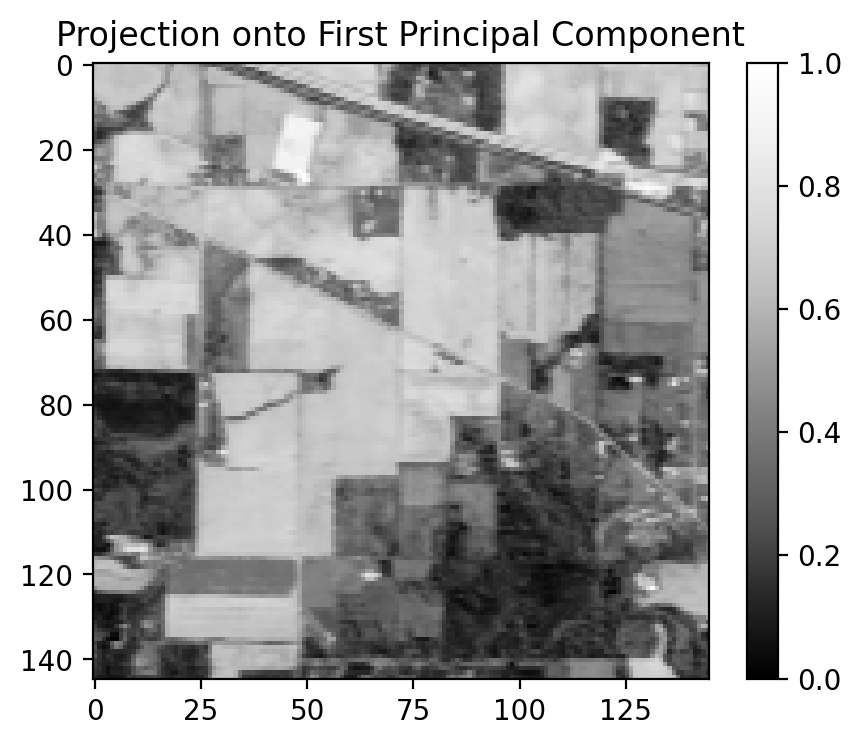

In [21]:
# Reshape into 2D image
img_pca = X_pca.reshape(nY,nX)

# Normalize to range [0,1] 
img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component')
pl.show()

In [22]:
ers = ERS()
ers.initialize(data3Darr, kernel=gaussian_kernel, sigma = std_norm)
#ers.initialize(img_pca, kernel=gaussian_kernel, sigma = 0.01)
ers.setParams(K=100, alpha=0.5)
ers.segment()


Number of clusters: 21025

Max Gain:  0.005488988368467165

Number of clusters: 21024

Max Gain:  0.005488488691370431

Number of clusters: 21023

Max Gain:  0.005488420334122508

Number of clusters: 21022

Max Gain:  0.005488414966683315

Number of clusters: 21021

Max Gain:  0.005488353230253207

Number of clusters: 21020

Max Gain:  0.0054882833730927226

Number of clusters: 21019

Max Gain:  0.005488255156965816

Number of clusters: 21018

Max Gain:  0.005488225281573922

Number of clusters: 21017

Max Gain:  0.00548817190689058

Number of clusters: 21016

Max Gain:  0.005488129675027682

Number of clusters: 21015

Max Gain:  0.005488055015432147

Number of clusters: 21014

Max Gain:  0.005488039942403921

Number of clusters: 21013

Max Gain:  0.005488027997027106

Number of clusters: 21012

Max Gain:  0.005488004621935558

Number of clusters: 21011

Max Gain:  0.005487990087231999

Number of clusters: 21010

Max Gain:  0.005487976645796492

Number of clusters: 21009

Max Gain:  0

ERS number of segments: 100


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037975464883877076..1.0000000000000007].


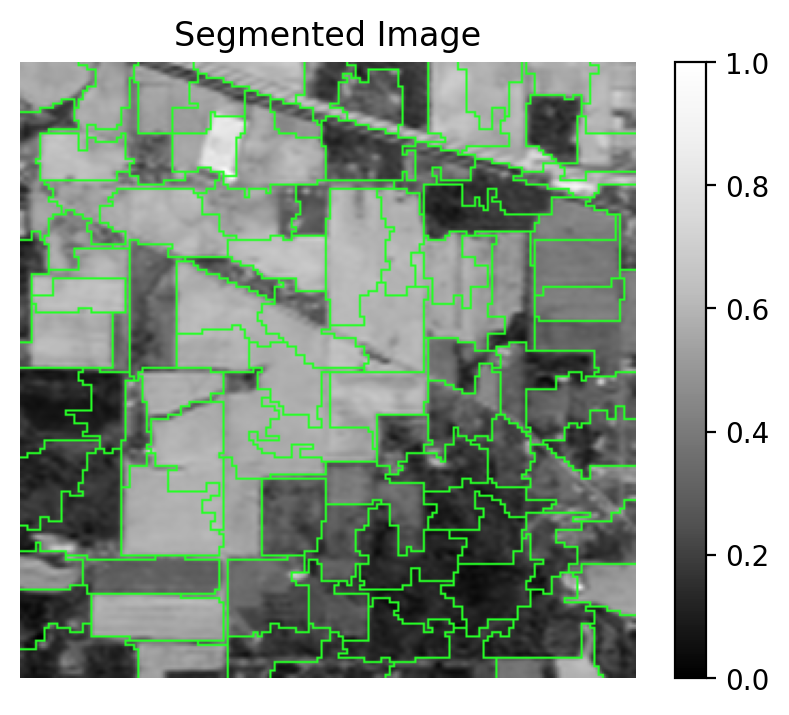

In [23]:
segments = ers.labels_matrix

from skimage.segmentation import mark_boundaries
from skimage import img_as_float
nSegments = len(np.unique(segments))
print(f'ERS number of segments: {nSegments}')

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
pl.title(r"Segmented Image")
pl.axis('off')
#pl.savefig('SLIC.png',dpi=600)
pl.colorbar()
pl.show()

In [24]:
segmentsVec = segments.reshape(nPix)

superpixelwise_dataMat, superpixelwise_indexVec = superpixelwiseDataMatFromGlobalDataMat(dataMat, segmentsVec)

Perform local superpixelwise reconstruction of each pixel

In [25]:
superpixelwise_reconstructedDataMat = []

k = 15

for i in range(nSegments):
    superpixelwise_reconstructedDataMat.append(reconstructSuperpixelDataMat(superpixelwise_dataMat[i],superpixelwise_indexVec[i],nX,k))

reconstructedDataMat = globalDataMatFromSuperpixelwiseDataMat(superpixelwise_reconstructedDataMat,superpixelwise_indexVec)

Perform PCA on reconstructed data

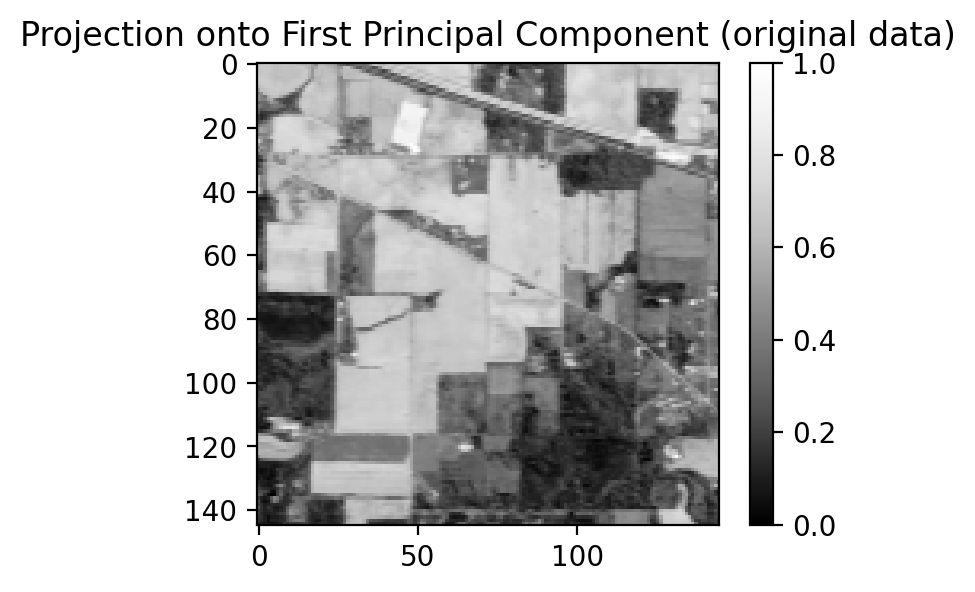

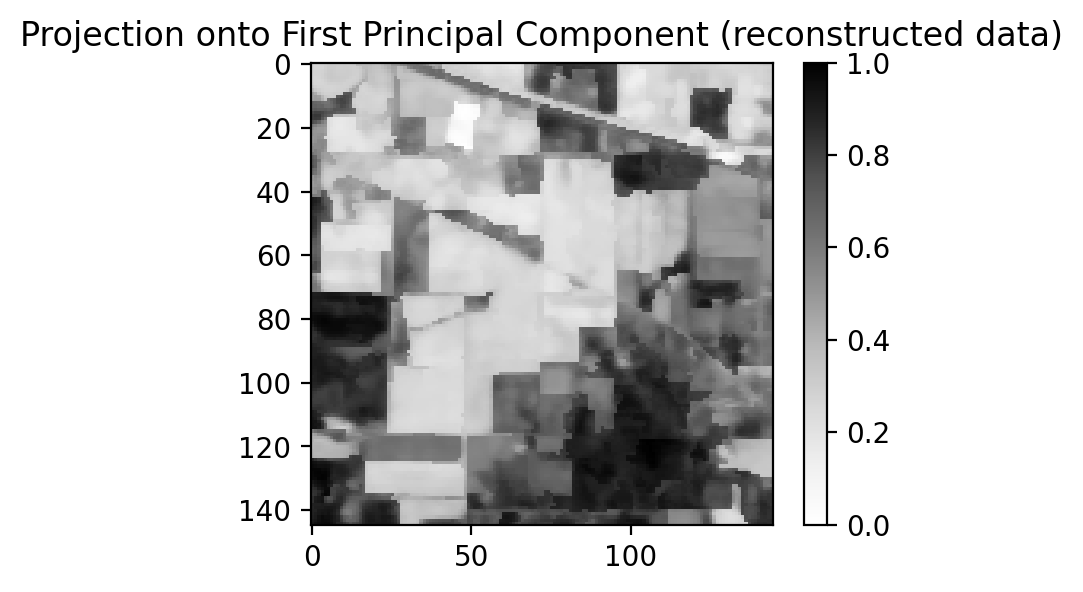

In [26]:
X2_pca, components = pca(reconstructedDataMat, 1)

# Reshape into 2D image
img2_pca = X2_pca.reshape(nY,nX)

# Normalize to range [0,1] for imshow
img2_pca = (img2_pca - np.min(img2_pca))/(np.max(img2_pca)-np.min(img2_pca))

fig, axes = pl.subplots(figsize=(4,3))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component (original data)')
pl.show()

fig, axes = pl.subplots(figsize=(4,3))
pl.imshow(img2_pca, cmap='Greys')
pl.colorbar()
pl.title('Projection onto First Principal Component (reconstructed data)')
pl.show()

Perform PCA on each superpixel

In [27]:
nComponents = 30

superpixelwise_reducedDataMat = []

for i in range(0,nSegments):
    
    segmenti_dataMatReduced, components = pca(superpixelwise_reconstructedDataMat[i], nComponents)
    superpixelwise_reducedDataMat.append(segmenti_dataMatReduced)
    
superpixelwiseReducedDataMat = globalDataMatFromSuperpixelwiseDataMat(superpixelwise_reducedDataMat, superpixelwise_indexVec)

Perform global PCA and concatenate

In [28]:
globalReducedMat, components = pca(reconstructedDataMat, nComponents)

intermediateDataMat = np.hstack((globalReducedMat, superpixelwiseReducedDataMat))

reducedDataMat, components = pca(intermediateDataMat, nComponents)

Perform SVM classification

In [34]:
# Import datasets, classifiers and performance metrics
from sklearn import metrics, svm

# Create indices for tracking
indices = np.arange(nPix)

# Split data into 30 training samples per label and remaining test samples
X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(reducedDataMat, labelsVec, 30)

# Convert 1D indices back to 2D coordinates
rows, cols = np.unravel_index(indices, img_pca.shape)


In [35]:
# Create a classifier: a support vector classifier
clf = svm.SVC(kernel = 'rbf')

# Define parameter grid
param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

from sklearn.model_selection import GridSearchCV

# Use GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'C': 10.0, 'gamma': 0.1}
Best cross-validation score: 0.9543340380549683


In [36]:
gamma = grid_search.best_params_['gamma']
C = grid_search.best_params_['C']

clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)

clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
predicted = clf.predict(X_test)

# Generate classification report
report = metrics.classification_report(y_test, predicted, output_dict=True)

print(
    f"Classification report for classifier {svm}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

# Extract overall accuracy
overall_accuracy = report["accuracy"]
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Classification report for classifier <module 'sklearn.svm' from 'c:\\Users\\shubh\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\sklearn\\svm\\__init__.py'>:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.93      0.86      0.89      1398
           3       0.96      0.97      0.96       800
           4       0.91      0.95      0.93       207
           5       1.00      0.92      0.96       453
           6       1.00      1.00      1.00       700
           7       0.93      0.93      0.93        14
           8       1.00      1.00      1.00       448
           9       1.00      1.00      1.00        10
          10       0.89      0.91      0.90       942
          11       0.96      0.97      0.97      2425
          12       0.90      0.96      0.93       563
          13       1.00      0.99      1.00       175
          14       1.00      1.00      1.00      1235
          15

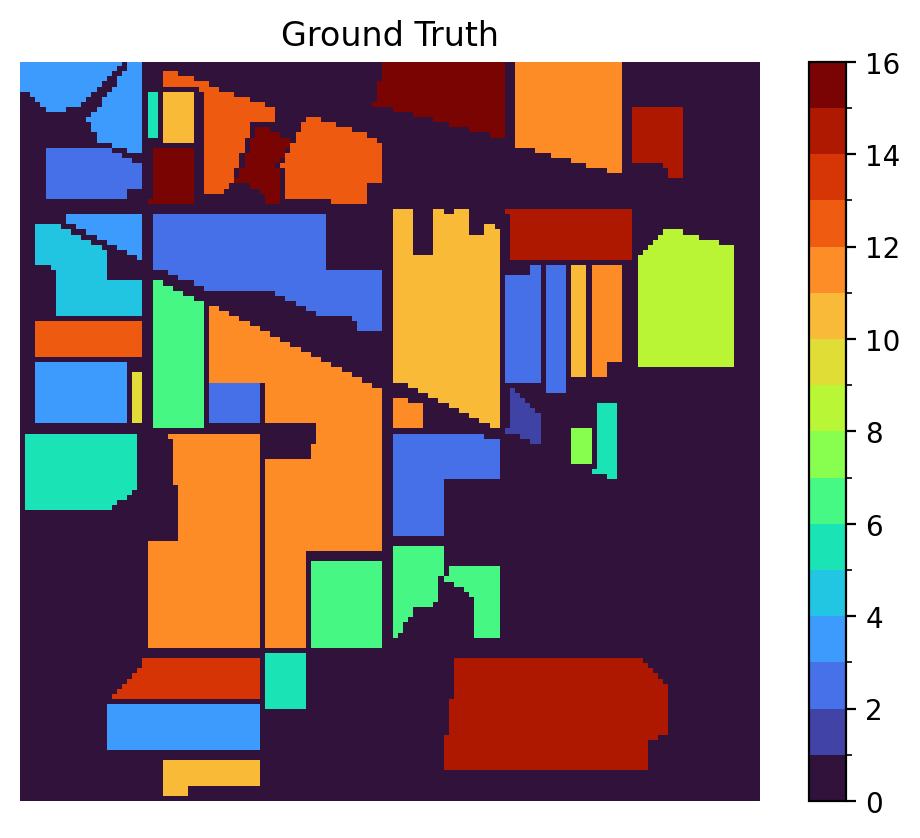

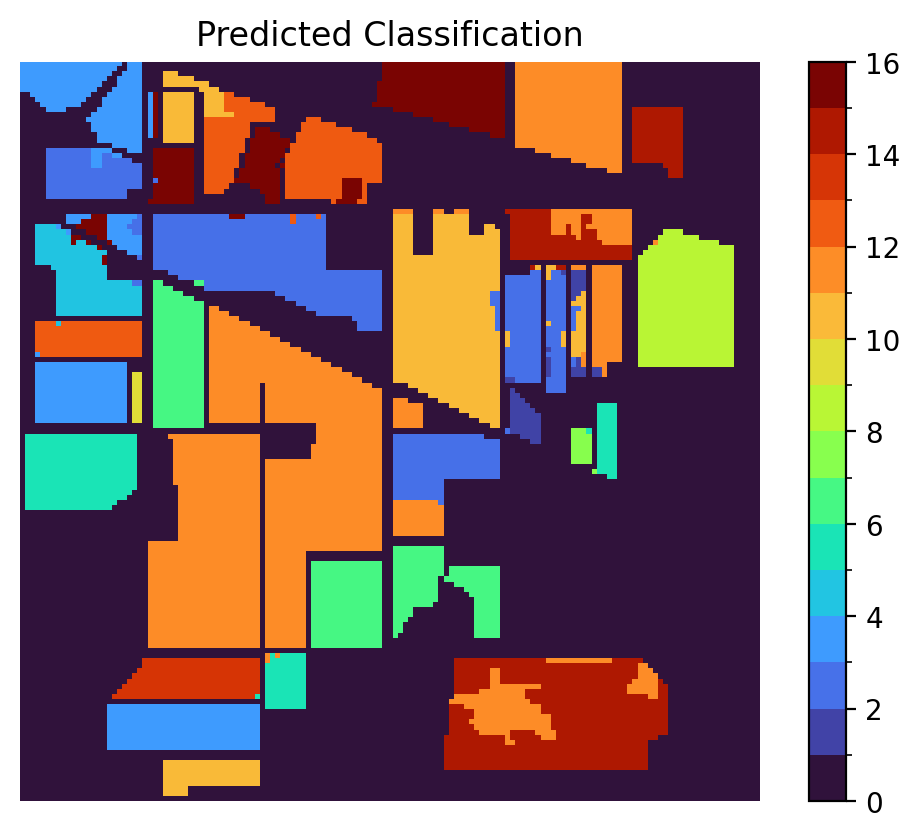

In [32]:
# Show predicted classification

labels_array_predicted = np.zeros(nPix)

labels_array_predicted[labelsVec != 0] = clf.predict(reducedDataMat[labelsVec != 0,:])

labels2D_array_predicted = labels_array_predicted.reshape(nY,nX)

pl.imshow(labelsMat, cmap=cmap,norm=norm)
pl.axis('off')
pl.colorbar()
pl.title(r"Ground Truth")
#pl.savefig('GroundTruth.png',dpi=600)
pl.show()
pl.imshow(labels2D_array_predicted, cmap=cmap,norm=norm)
pl.axis('off')
pl.colorbar()
pl.title(r"Predicted Classification")
pl.savefig('S3PCA_ERS.png',dpi=600)
pl.show()